<a href="https://colab.research.google.com/github/Rakesh114166/Rakesh-dock/blob/main/Rakesh_dock_live.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title CELL 1: Robust System Environment Setup { display-mode: "form" }
#@markdown Run this cell to completely purge cached package conflicts and deploy the clean computational informatics stack.

import sys
import subprocess
import os

# --- Step 1: PURGE CACHE AND LEGACY PACKAGES ---
# Removes old configurations and broken source installations that prevent smooth deployment.
print("[-] Clearing cached package configurations and broken artifacts...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "openbabel", "openbabel-wheel", "plip", "rdkit", "py3Dmol", "pandas"], check=False)
subprocess.run(["sudo", "apt-get", "purge", "-y", "openbabel", "libopenbabel-dev"], check=False)

# --- Step 2: UPDATE SYSTEM REGISTRIES & BUILD TOOLS ---
# Updates the base OS registry and, CRITICALLY, modernizes Python's core build ecosystem.
print("[-] Updating system registries and modernizing core Python build tools...")
subprocess.run(["sudo", "apt-get", "update", "-qq"], check=True)
# libopenbabel-dev and swig are often required by PLIP to compile specific extensions seamlessly.
subprocess.run(["sudo", "apt-get", "install", "-y", "-qq", "openbabel", "libopenbabel-dev", "swig"], check=True)
# Explicitly upgrading pip, setuptools, and wheel prevents standard Status 1 install errors on any machine.
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"], check=True)

# --- Step 3: STATIC BINARY DEPLOYMENT (AutoDock Vina) ---
# Deploys the uncompressed static Vina binary directly into the execution PATH.
print("[-] Deploying static binary for AutoDock Vina v1.2.5...")
vina_url = "https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64"
vina_path = "/usr/local/bin/vina"
subprocess.run(["wget", "-q", vina_url, "-O", vina_path], check=True)
subprocess.run(["chmod", "+x", vina_path], check=True)

# --- Step 4: CORE INFORMATICS STACK & PLIP DEPLOYMENT ---
# Installs packages without silencing output so errors can be instantly diagnosed.
print("[-] Deploying foundational chemical informatics stack (RDKit, py3Dmol, pandas)...")
# Removed quiet flag "-q" for robustness.
subprocess.run([sys.executable, "-m", "pip", "install", "rdkit", "py3Dmol", "pandas"], check=True)

print("[-] Deploying stable pre-compiled OpenBabel wheels...")
# Installs openbabel-wheel first to satisfy PLIP's dependency without broken source compilation.
subprocess.run([sys.executable, "-m", "pip", "install", "openbabel-wheel"], check=True)

print("[-] Deploying interaction profiler engine (PLIP) via standard dependency resolution...")
# Installed normally, pip will recognize openbabel-wheel satisfies the dependency.
subprocess.run([sys.executable, "-m", "pip", "install", "plip"], check=True)

print("\n[+] SYSTEM CONFIGURATION DEPLOYED SUCCESSFULLY")
print(f"    ↳ Vina Version: {subprocess.getoutput('vina --version').splitlines()[0]}")
print(f"    ↳ Babel CLI: {subprocess.getoutput('obabel -V').strip()}")

[-] Clearing cached package configurations and broken artifacts...
[-] Updating system registries and modernizing core Python build tools...
[-] Deploying static binary for AutoDock Vina v1.2.5...
[-] Deploying foundational chemical informatics stack (RDKit, py3Dmol, pandas)...
[-] Deploying stable pre-compiled OpenBabel wheels...
[-] Deploying interaction profiler engine (PLIP) via standard dependency resolution...

[+] SYSTEM CONFIGURATION DEPLOYED SUCCESSFULLY
    ↳ Vina Version: AutoDock Vina v1.2.5
    ↳ Babel CLI: Open Babel 3.1.0 -- Feb 17 2026 -- 06:47:59


In [2]:
#@title CELL 2: Core Module Initialization { display-mode: "form" }
#@markdown Initializes standard, specialized, and structural module dependencies into the namespace.

import os
import sys
import subprocess

print("[-] Verifying core ecosystem stability and binding paths...")

try:
    import pandas as pd
    import py3Dmol
    import rdkit
    from rdkit import Chem
    from rdkit.Chem import AllChem
    import plip
    from plip.structure.preparation import PDBComplex

    print("\n[+] CORE ENVIRONMENT INITIALIZED SUCCESSFULLY")
    print(f"    ↳ Interpreter Platform   : Python {sys.version.split()[0]}")
    print(f"    ↳ Pandas Data Matrix API : v{pd.__version__}")
    print(f"    ↳ RDKit Core Engine      : v{rdkit.__version__}")
    print(f"    ↳ PLIP Profiler Binding  : Active and stable")

except Exception as e:
    print(f"\n[!] Initialization Failure: {e}")
    print("    ↳ Action Required: Go to the top menu, click 'Runtime' -> 'Restart Session', then re-run CELL 1 and CELL 2.")

[-] Verifying core ecosystem stability and binding paths...

[+] CORE ENVIRONMENT INITIALIZED SUCCESSFULLY
    ↳ Interpreter Platform   : Python 3.12.13
    ↳ Pandas Data Matrix API : v3.0.3
    ↳ RDKit Core Engine      : v2026.03.2
    ↳ PLIP Profiler Binding  : Active and stable


In [3]:
#@title CELL 3: Project Directory Layout Generator { display-mode: "form" }
#@markdown Enter a `< Job Name >` without spaces to establish your workspace directories.

Job_name = "3O3U_VS" #@param {type:"string"}

import os

# Strict input verification matching the original layout rules
assert not Job_name == "", "Do not leave this blank."
assert not any(c == "/" or c == "." or c == " " for c in Job_name), "Disallowed characters detected in your Job Name."

print(f"[-] Initializing project workspace root for simulation tracking: '{Job_name}'")

# Map out absolute directory paths matching your workflow chart layout
BASE_DIR = os.getcwd()
WRK_DIR  = os.path.join(BASE_DIR, Job_name)
PRT_FLD  = os.path.join(WRK_DIR, "PROTEIN")
LIG_FLD  = os.path.join(WRK_DIR, "LIGAND")
EXP_FLD  = os.path.join(WRK_DIR, "EXPERIMENTAL")
DCK_FLD  = os.path.join(WRK_DIR, "DOCKING")
INT_FLD  = os.path.join(WRK_DIR, "INTERACTION")

folders = [WRK_DIR, PRT_FLD, LIG_FLD, EXP_FLD, DCK_FLD, INT_FLD]

for f in folders:
    if os.path.exists(f):
        print(f"    [!] Notice: Node element folder already exists -> {os.path.basename(f)}")
    else:
        os.makedirs(f, exist_ok=True)
        print(f"    [->] Successfully Generated Directory Folder Node: {f}")

# Inject path mappings into environmental variables for clean cross-cell data handshake
os.environ['WRK_DIR'] = WRK_DIR
os.environ['PRT_FLD'] = PRT_FLD
os.environ['LIG_FLD'] = LIG_FLD
os.environ['EXP_FLD'] = EXP_FLD
os.environ['DCK_FLD'] = DCK_FLD
os.environ['INT_FLD'] = INT_FLD

print("\n[+] WORKSPACE PATHWAYS ASSIGNED SUCCESSFULLY")
print(f"    ↳ Active Project Root Directory: {os.environ['WRK_DIR']}")

[-] Initializing project workspace root for simulation tracking: '3O3U_VS'
    [->] Successfully Generated Directory Folder Node: /content/3O3U_VS
    [->] Successfully Generated Directory Folder Node: /content/3O3U_VS/PROTEIN
    [->] Successfully Generated Directory Folder Node: /content/3O3U_VS/LIGAND
    [->] Successfully Generated Directory Folder Node: /content/3O3U_VS/EXPERIMENTAL
    [->] Successfully Generated Directory Folder Node: /content/3O3U_VS/DOCKING
    [->] Successfully Generated Directory Folder Node: /content/3O3U_VS/INTERACTION

[+] WORKSPACE PATHWAYS ASSIGNED SUCCESSFULLY
    ↳ Active Project Root Directory: /content/3O3U_VS


In [4]:
#@title CELL 4: Receptor Chain Isolation & Parameterization { display-mode: "form" }
#@markdown Download target PDB structures, isolate desired protein chains, strip water matrices, and parameterize to PDBQT.

PDB_ID = "3O3U" #@param {type:"string"}
CHAIN_ID = "N" #@param {type:"string"}

import os
import urllib.request
import subprocess
import py3Dmol

# Fetch target directories from the environment variables set in Cell 3
PRT_FLD = os.environ.get('PRT_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not PRT_FLD or not DCK_FLD:
    raise ValueError("Workspace directories not detected. Please run Cell 3 first to generate paths.")

# Dynamically construct filenames to match your workflow schema exactly
base_name = f"{PDB_ID.upper()}_prot_{CHAIN_ID.upper()}"
raw_pdb_path = os.path.join(PRT_FLD, f"{PDB_ID.lower()}.pdb")
clean_pdb_path = os.path.join(PRT_FLD, f"{base_name}.pdb")
docking_pdb_copy = os.path.join(DCK_FLD, f"{base_name}.pdb")
receptor_pdbqt = os.path.join(DCK_FLD, f"{base_name}.pdbqt")

print(f"[-] Fetching crystal structure '{PDB_ID.upper()}' securely from RCSB PDB Repository...")
url = f"https://files.rcsb.org/download/{PDB_ID.upper()}.pdb"
try:
    urllib.request.urlretrieve(url, raw_pdb_path)
    print(f"    ↳ PDB downloaded: {PDB_ID.lower()}.pdb ==> PROTEIN folder")
except Exception as e:
    raise RuntimeError(f"Network error: Unable to retrieve PDB file {PDB_ID}. Details: {e}")

print(f"[-] Extracting protein: Isolating Chain '{CHAIN_ID}' and clearing water matrices...")
atom_count = 0

with open(raw_pdb_path, 'r') as infile, open(clean_pdb_path, 'w') as outfile:
    for line in infile:
        # Capture standard amino acid backbone rows (ATOM)
        if line.startswith("ATOM  "):
            line_chain = line[21].strip()
            # If a specific chain is required, match it; otherwise extract all chains
            if line_chain == CHAIN_ID or not CHAIN_ID:
                outfile.write(line)
                atom_count += 1
        # Maintain core structural break coordinates
        elif line.startswith("TER   ") or line.startswith("ENDMDL"):
            if atom_count > 0:  # Only write breaks if we have already isolated atoms for this frame
                outfile.write(line)

if atom_count == 0:
    raise ValueError(f"Target isolation failed: No ATOM records found matching Chain '{CHAIN_ID}'.")
print(f"    ↳ Protein extracted: {PDB_ID.lower()}.pdb --> {base_name}.pdb")

# Sync clean PDB file over to the DOCKING folder to match original tutorial architecture
with open(clean_pdb_path, 'r') as src, open(docking_pdb_copy, 'w') as dst:
    dst.write(src.read())

print("[-] Running structural parameterization and Gasteiger charge assignment via OpenBabel...")
# -xr builds a rigid receptor by preserving atom records and blocking bond rotations
cmd = ["obabel", clean_pdb_path, "-O", receptor_pdbqt, "-xr", "--partialcharge", "gasteiger"]
subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print(f"    ↳ Protein parameterized: {base_name}.pdb --> {base_name}.pdbqt")
print(f"    ↳ {base_name}.pdb ==> DOCKING folder")
print(f"    ↳ {base_name}.pdbqt ==> DOCKING folder")

# Render the isolated receptor backbone interactively
print("\n[-] Displaying 3D protein macromolecular architecture...")
view = py3Dmol.view(width=650, height=450)
with open(clean_pdb_path, 'r') as f:
    view.addModel(f.read(), 'pdb')
view.setStyle({'cartoon': {'color': 'spectrum'}})
view.zoomTo()
view.show()

[-] Fetching crystal structure '3O3U' securely from RCSB PDB Repository...
    ↳ PDB downloaded: 3o3u.pdb ==> PROTEIN folder
[-] Extracting protein: Isolating Chain 'N' and clearing water matrices...
    ↳ Protein extracted: 3o3u.pdb --> 3O3U_prot_N.pdb
[-] Running structural parameterization and Gasteiger charge assignment via OpenBabel...
    ↳ Protein parameterized: 3O3U_prot_N.pdb --> 3O3U_prot_N.pdbqt
    ↳ 3O3U_prot_N.pdb ==> DOCKING folder
    ↳ 3O3U_prot_N.pdbqt ==> DOCKING folder

[-] Displaying 3D protein macromolecular architecture...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
#@title CELL 5: Experimental Native Control Extraction { display-mode: "form" }
#@markdown Enter the official 3-letter residue code for the co-crystallized control drug present inside the target crystal structure (e.g., NAG, PY1, STI).

Crystallized_Ligand_ID = "SO4" #@param {type:"string"}

import os
import subprocess

# Retrieve absolute directory pathways from environmental memory set in Cell 3
PRT_FLD = os.environ.get('PRT_FLD')
EXP_FLD = os.environ.get('EXP_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not all([PRT_FLD, EXP_FLD, DCK_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

# Standardize input code token string to upper-case matching standard PDB formatting conventions
lig_code = Crystallized_Ligand_ID.strip().upper()

# Clear out any stale historical control structures inside the docking track workspace
for folder in [EXP_FLD, DCK_FLD]:
    for f in os.listdir(folder):
        if f.endswith(('.pdb', '.pdbqt')) and not "_prot_" in f:
            os.remove(os.path.join(folder, f))

# Detect source macro-structural coordinate target file generated by Cell 4
raw_pdb_candidates = [f for f in os.listdir(PRT_FLD) if f.endswith('.pdb') and not '_prot_' in f]

if not raw_pdb_candidates:
    print("[!] Error: No baseline reference PDB files discovered inside the PROTEIN workspace folder.")
    print("    ↳ Action required: Ensure CELL 4 executed successfully before running control extractions.")
else:
    source_pdb_path = os.path.join(PRT_FLD, raw_pdb_candidates[0])

    if not lig_code or len(lig_code) != 3:
        print("[+] Notice: Bypassing co-crystallized control drug isolation routine.")
        print("    ↳ Running pipeline in Apoprotein mode. Downstream cells will utilize manual slider coordinate boundaries.")
    else:
        print(f"[-] Scanning crystal matrices for reference control ligand token: [{lig_code}]")

        extracted_lines = []
        with open(source_pdb_path, 'r') as pdb_file:
            for line in pdb_file:
                # Intercept coordinate maps matching HETATM or ATOM configurations for the target identifier token
                if (line.startswith("HETATM") or line.startswith("ATOM")) and line[17:20].strip() == lig_code:
                    extracted_lines.append(line)

        if not extracted_lines:
            print(f"[!] Warning: Coordinate token '{lig_code}' was not found inside the active PDB structure matrix.")
            print("    ↳ Downstream grid calculations will default automatically back to manual slider configurations.")
        else:
            print(f"[+] Discovered {len(extracted_lines)} atom coordinate vectors for target ligand [{lig_code}].")

            # Destination path maps for programmatic parsing tracking
            raw_lig_pdb = os.path.join(EXP_FLD, f"{lig_code}.pdb")
            dck_lig_pdb = os.path.join(DCK_FLD, f"{lig_code}.pdb")
            dck_lig_pdbqt = os.path.join(DCK_FLD, f"{lig_code}.pdbqt")

            # Write out pure un-parameterized reference coordinate file
            with open(raw_lig_pdb, 'w') as out_f:
                out_f.writelines(extracted_lines)
                out_f.write("END\n")

            # Mirror clean coordinate blueprint into active docking track space
            with open(dck_lig_pdb, 'w') as out_f:
                out_f.writelines(extracted_lines)
                out_f.write("END\n")

            print(f"[-] Parameterizing charge topologies and protonating control drug coordinate lines at pH 7.4...")

            # Utilize OpenBabel to correctly add hydrogen geometries and calculate standard internal partial charge profiles
            cmd_babel = [
                "obabel", raw_lig_pdb,
                "-O", dck_lig_pdbqt,
                "-p", "7.4",
                "--partialcharge", "gasteiger"
            ]

            convert_job = subprocess.run(cmd_babel, capture_output=True, text=True)

            if os.path.exists(dck_lig_pdbqt) and os.path.getsize(dck_lig_pdbqt) > 0:
                print(f"\n[+] NATIVE REFERENCE BASELINE ARTIFACT GENERATED:")
                print(f"    ↳ Extracted Crystal Model   -> {raw_lig_pdb}")
                print(f"    ↳ Parameterized Vina Model -> {dck_lig_pdbqt}")
                print(f"    ↳ Configuration Status      -> Ready for downstream grid alignment visualization.")
            else:
                print(f"[!] Critical Parameterization Failure. OpenBabel logging output:\n{convert_job.stderr}")

[-] Scanning crystal matrices for reference control ligand token: [SO4]
[+] Discovered 5 atom coordinate vectors for target ligand [SO4].
[-] Parameterizing charge topologies and protonating control drug coordinate lines at pH 7.4...

[+] NATIVE REFERENCE BASELINE ARTIFACT GENERATED:
    ↳ Extracted Crystal Model   -> /content/3O3U_VS/EXPERIMENTAL/SO4.pdb
    ↳ Parameterized Vina Model -> /content/3O3U_VS/DOCKING/SO4.pdbqt
    ↳ Configuration Status      -> Ready for downstream grid alignment visualization.


In [6]:
#@title CELL 5.5: Studio-Grade Interactive Molecular Workbench { display-mode: "form" }
#@markdown Adjust the visual parameters below to customize your 3D macromolecular workspace representation.

#@markdown ---
#@markdown ### 🏛️ Protein Target Architecture Settings:
Protein_Style = "cartoon" #@param ["cartoon", "stick", "sphere", "line", "trace"]
Protein_Color_Palette = "spectrum (rainbow)" #@param ["spectrum (rainbow)", "secondary structure (ssJmol)", "elegant slate", "marine blue", "chalky white"]
Binding_Pocket_Residues = "highlight sidechains (5\u00C5)" #@param ["hide", "highlight sidechains (5\u00C5)", "highlight backbones (5\u00C5)"]

#@markdown ---
#@markdown ### 🔑 Co-Crystallized Control Ligand Settings:
Ligand_Style = "stick + sphere" #@param ["stick + sphere", "thick stick", "spacefill sphere", "wireframe"]
Ligand_Color_Scheme = "element (CPK classic)" #@param ["element (CPK classic)", "vibrant yellow carbon", "neon cyan carbon"]

#@markdown ---
#@markdown ### ☁️ Solvent / Pocket Surface Clouds:
Surface_Type = "Solvent Excluded (SES)" #@param ["none", "Solvent Excluded (SES)", "Solvent Accessible (SAS)", "Van der Waals (VDW)"]
Surface_Color = "electrostatic guess (red/blue)" #@param ["soft uniform gray", "match atom element", "electrostatic guess (red/blue)"]
Surface_Opacity = 0.7 #@param {type:"slider", min:0, max:1, step:0.05}

#@markdown ---
#@markdown ### 🎬 Cinematic Extras:
Spin_Animation = True #@param {type:"boolean"}
Background_Color = "pristine white" #@param ["pristine white", "deep charcoal", "pitch black"]

import os
import py3Dmol

# Retrieve absolute directory pathways from environmental memory
DCK_FLD = os.environ.get('DCK_FLD')
if not DCK_FLD or not os.path.exists(DCK_FLD):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 and Cell 4 first.")

prot_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdbqt') and "_prot_" in f]
control_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith(('.pdbqt', '.pdb')) and not "_prot_" in f and not "_output" in f]

if not prot_candidates or not control_candidates:
    print("[!] Components missing. Ensure Cell 4 and Cell 5 ran completely.")
else:
    # --- RESOLVE BACKGROUND THEMES ---
    bg_dict = {"pristine white": "#F8FAFC", "deep charcoal": "#1E293B", "pitch black": "#000000"}
    bg_color = bg_dict.get(Background_Color, "#F8FAFC")

    with open(os.path.join(DCK_FLD, prot_candidates[0]), 'r') as f:
        protein_data = f.read()
    with open(os.path.join(DCK_FLD, control_candidates[0]), 'r') as f:
        ligand_data = f.read()

    # Initialize canvas dimensions
    viewer = py3Dmol.view(width=850, height=550)
    viewer.setBackgroundColor(bg_color)

    # 1. INJECT RECEPTOR TARGET LAYER (Model 0)
    viewer.addModel(protein_data, "pdb")

    # Handle advanced protein color themes
    if Protein_Color_Palette == "spectrum (rainbow)":
        prot_style_spec = {Protein_Style: {'colorscheme': 'spectrum'}}
    elif Protein_Color_Palette == "secondary structure (ssJmol)":
        prot_style_spec = {Protein_Style: {'colorscheme': 'ssJmol'}}
    else:
        hex_colors = {"elegant slate": "#94A3B8", "marine blue": "#3B82F6", "chalky white": "#E2E8F0"}
        prot_style_spec = {Protein_Style: {'color': hex_colors.get(Protein_Color_Palette, "#94A3B8"), 'opacity': 0.85}}

    viewer.setStyle({'model': 0}, prot_style_spec)

    # 2. ENGAGE BINDING POCKET AUTOMATION INTERCEPTOR
    # Targets receptor atoms residing within a 5.0 Angstrom sphere of the control ligand model (Model 1)
    if Binding_Pocket_Residues != "hide":
        pocket_selection = {'model': 0, 'within': {'distance': 5.0, 'sel': {'model': 1}}}
        if "sidechains" in Binding_Pocket_Residues:
            viewer.setStyle(pocket_selection, {'stick': {'colorscheme': 'elementOres', 'radius': 0.18}})
        elif "backbones" in Binding_Pocket_Residues:
            viewer.setStyle(pocket_selection, {'line': {'colorscheme': 'elementOres'}})

    # 3. INJECT CONTROL LIGAND TARGET LAYER (Model 1)
    viewer.addModel(ligand_data, "pdb")

    # Configure custom carbon colors for immediate visual contrast
    lig_colors = {
        "element (CPK classic)": "elementOres",
        "vibrant yellow carbon": "yellowCarbon",
        "neon cyan carbon": "cyanCarbon"
    }
    chosen_lig_color = lig_colors.get(Ligand_Color_Scheme, "elementOres")

    if Ligand_Style == "stick + sphere":
        viewer.setStyle({'model': 1}, {
            'stick': {'colorscheme': chosen_lig_color, 'radius': 0.23},
            'sphere': {'colorscheme': chosen_lig_color, 'scale': 0.23}
        })
    elif Ligand_Style == "thick stick":
        viewer.setStyle({'model': 1}, {'stick': {'colorscheme': chosen_lig_color, 'radius': 0.38}})
    elif Ligand_Style == "spacefill sphere":
        viewer.setStyle({'model': 1}, {'sphere': {'colorscheme': chosen_lig_color, 'scale': 0.85}})
    elif Ligand_Style == "wireframe":
        viewer.setStyle({'model': 1}, {'line': {'colorscheme': chosen_lig_color}})

    # 4. COMPUTE ADVANCED 3D MOLECULAR POCKET SURFACES
    if Surface_Type != "none":
        surf_types = {"Solvent Excluded (SES)": py3Dmol.SES, "Solvent Accessible (SAS)": py3Dmol.SAS, "Van der Waals (VDW)": py3Dmol.VDW}
        chosen_surf = surf_types.get(Surface_Type, py3Dmol.SES)

        surf_style = {'opacity': Surface_Opacity}
        if Surface_Color == "soft uniform gray":
            surf_style['color'] = '#CBD5E1'
        elif Surface_Color == "match atom element":
            surf_style['colorscheme'] = 'elementOres'
        elif Surface_Color == "electrostatic guess (red/blue)":
            surf_style['colorscheme'] = 'vdw' # Maps atomic radius gradients as an aesthetic substitute

        viewer.addSurface(chosen_surf, surf_style, {'model': 0})

    # Center camera on active ligand pocket site coordinates
    viewer.zoomTo({'model': 1})

    # Toggle runtime physics animation
    if Spin_Animation:
        viewer.animate({'loop': 'forward', 'step': 1})

    viewer.show()
    print("[+] Workspace initialized with advanced presentation metrics. Ready for analysis.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[+] Workspace initialized with advanced presentation metrics. Ready for analysis.


In [8]:
#@title CELL 6: CSV High-Throughput Ligand Preparation { display-mode: "form" }
#@markdown Batch-process an uploaded spreadsheet of compounds from SMILES to optimized 3D PDBQT structures.

Compound_library = "MONAMI.csv" #@param {type:"string"}
Select_force_field = "UFF" #@param ["GAFF", "Ghemical", "MMFF94", "MMFF94s", "UFF"]
Max_minimization_steps = 10000 #@param {type:"slider", min:1000, max:20000, step:1000}
View_ligand = "SKQ1" #@param {type:"string"}

import os
import shutil
import subprocess
import pandas as pd
import py3Dmol

# Retrieve absolute directory trees from the environment variables set in Cell 3
WRK_DIR = os.environ.get('WRK_DIR')
LIG_FLD = os.environ.get('LIG_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not all([WRK_DIR, LIG_FLD, DCK_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

CL_csv_Lfile = os.path.join(LIG_FLD, Compound_library)

# --- AUTOMATED TEMPLATE GENERATOR ---
if not os.path.exists(CL_csv_Lfile):
    print(f"[!] Alert: Spreadsheet template '{Compound_library}' not detected inside LIGAND folder.")
    print("    ↳ Generating a fresh screening library containing PY1 (control), Naringenin, and Esculin...")
    sample_payload = {
        "ID": ["PY1", "NARINGENIN", "ESCULIN"],
        "SMILES": [
            "C1=CC=C2C(=C1)C(=CC=N2)C3=CNN=C3C4=CC=CC=N4", # PY1 (True 1PY5 Control Drug)
            "O=C1CC(C2=CC=C(O)C=C2)OC3=CC(O)=CC(O)=C13",     # Naringenin
            "O=C1C=C(O[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)C3=C(O)C=CC(=C3O1)" # Esculin
        ]
    }
    pd.DataFrame(sample_payload).to_csv(CL_csv_Lfile, index=False)

# Read library using the exact string column indexing from your video layout
try:
    ligDF = pd.read_csv(CL_csv_Lfile, dtype=str)
    lig_IDs = tuple(ligDF["ID"].str.strip().str.upper())
    lig_SMILES = tuple(ligDF["SMILES"].str.strip())
except Exception as e:
    raise RuntimeError(f"Failed to read chemical library layout matrix: {e}")

print(f"[+] Loaded chemical target library spreadsheet. Processing {len(lig_IDs)} compounds...")

# Step 1: Write raw .smi structural seed rows to disk
for N, ID in enumerate(lig_IDs):
    smi_file = os.path.join(LIG_FLD, f"{ID}.smi")
    with open(smi_file, "w") as o:
        o.write(lig_SMILES[N])

print(f"    ↳ + {len(lig_IDs)} ligand.smi ==> LIGAND folder")

# Step 2: High-Performance 3D Coordinate Mapping & Charge Parameterization Loop
for N, ID in enumerate(lig_IDs):
    smi_file = os.path.join(LIG_FLD, f"{ID}.smi")
    mol2_file = os.path.join(WRK_DIR, f"{ID}.mol2")
    final_mol2_path = os.path.join(LIG_FLD, f"{ID}.mol2")

    # Establish separate subfolders for each ligand inside DOCKING
    lig_Dfld = os.path.join(DCK_FLD, ID)
    os.makedirs(lig_Dfld, exist_ok=True)
    pdbqt_file = os.path.join(lig_Dfld, f"{ID}.pdbqt")

    # Run structural minimization macro-loop via modern OpenBabel CLI
    # Generates lowest-energy 3D conformations using your chosen force field selection
    cmd_minimize = [
        "obabel", smi_file, "-O", mol2_file,
        "--gen3d", "--best", "--canonical",
        "--minimize", "--ff", Select_force_field,
        "--steps", str(Max_minimization_steps)
    ]
    subprocess.run(cmd_minimize, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # Move minimized .mol2 transition file to LIGAND folder to preserve workspace architecture
    if os.path.exists(mol2_file):
        shutil.move(mol2_file, final_mol2_path)

    # Parameterize .mol2 structure to target .pdbqt docking profile with Gasteiger charges at pH 7.4
    cmd_parameterize = [
        "obabel", final_mol2_path, "-O", pdbqt_file,
        "-ph", "7.4", "--partialcharge", "gasteiger"
    ]
    subprocess.run(cmd_parameterize, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print(f"    ↳ + {len(lig_IDs)} ligand.mol2 ==> LIGAND folder")
print(f"    ↳ + {len(lig_IDs)} ligand.pdbqt ==> DOCKING folder subdirectories")
print(f"\n[+] HIGH-THROUGHPUT LIGAND PREPARATION COMPLETE USING FORCE FIELD: {Select_force_field}")

# Step 3: Interactive 3D Conformer Viewer Panel
target_view_mol2 = os.path.join(LIG_FLD, f"{View_ligand.strip().upper()}.mol2")

if os.path.exists(target_view_mol2):
    print(f"\n[-] Displaying 3D optimized chemical conformation for: {View_ligand.upper()}")
    view = py3Dmol.view(width=650, height=450)
    with open(target_view_mol2, 'r') as f:
        view.addModel(f.read(), 'mol2')
    view.setStyle({'stick': {'colorscheme': 'greenCarbon'}})
    view.zoomTo()
    view.show()
else:
    print(f"\n[!] View Alert: Cannot display 3D structure for '{View_ligand.upper()}'. ID not found in library.")

[+] Loaded chemical target library spreadsheet. Processing 2 compounds...
    ↳ + 2 ligand.smi ==> LIGAND folder
    ↳ + 2 ligand.mol2 ==> LIGAND folder
    ↳ + 2 ligand.pdbqt ==> DOCKING folder subdirectories

[+] HIGH-THROUGHPUT LIGAND PREPARATION COMPLETE USING FORCE FIELD: UFF

[-] Displaying 3D optimized chemical conformation for: SKQ1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [14]:
#@title CELL 6.5: Intelligent Grid Box Predictor { display-mode: "form" }
#@markdown Select your target screening ligand to automatically calculate the exact binding center and predict the optimal box size.

Target_Screening_Ligand = "SKQ1" #@param {type:"string"}

import os
import numpy as np

DCK_FLD = os.environ.get('DCK_FLD')
if not DCK_FLD or not os.path.exists(DCK_FLD):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

lig_id = Target_Screening_Ligand.strip().upper()
custom_lig_path = os.path.join(DCK_FLD, lig_id, f"{lig_id}.pdbqt")

# 1. Locate the co-crystallized control ligand to find the exact target center
control_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith(('.pdbqt', '.pdb')) and not "_prot_" in f and not "_output" in f]

if not control_candidates:
    print("[!] Error: No co-crystallized control ligand found. Ensure Cell 5 completed successfully.")
elif not os.path.exists(custom_lig_path):
    print(f"[!] Error: Missing target structural file for custom ligand [{lig_id}] at: {custom_lig_path}")
    print("    ↳ Double check your spelling or verify that your CSV library uploaded correctly.")
else:
    # --- STEP 1: CALCULATE EXACT CENTER OF CO-CRYSTALLIZED LIGAND ---
    ref_x, ref_y, ref_z = [], [], []
    with open(os.path.join(DCK_FLD, control_candidates[0]), 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                try:
                    ref_x.append(float(line[30:38].strip()))
                    ref_y.append(float(line[38:46].strip()))
                    ref_z.append(float(line[46:54].strip()))
                except ValueError:
                    continue

    cx = (max(ref_x) + min(ref_x)) / 2
    cy = (max(ref_y) + min(ref_y)) / 2
    cz = (max(ref_z) + min(ref_z)) / 2

    # --- STEP 2: MEASURE MAXIMUM EXTENSION OF YOUR CUSTOM LIGAND ---
    cust_coords = []
    with open(custom_lig_path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                try:
                    cust_coords.append([
                        float(line[30:38].strip()),
                        float(line[38:46].strip()),
                        float(line[46:54].strip())
                    ])
                except ValueError:
                    continue

    # Calculate the maximum tip-to-tip distance (diameter) of your custom molecule
    cust_coords = np.array(cust_coords)
    max_diameter = 15.0 # Enforce a safe standard baseline minimum size

    if len(cust_coords) > 1:
        # Compute pairwise distances between all atoms to find maximum length
        dists = plt.spatial.distance.pdist(cust_coords) if 'plt' in locals() else []
        # Native numpy calculation for efficiency and independence
        num_atoms = len(cust_coords)
        for i in range(num_atoms):
            for j in range(i + 1, num_atoms):
                d = np.linalg.norm(cust_coords[i] - cust_coords[j])
                if d > max_diameter:
                    max_diameter = d

    # Add a mandatory +5.0 Angstrom buffer comfort padding for free rotation
    predicted_box_size = ceil_size = int(np.ceil(max_diameter + 5.0))
    # Enforce standard Vina safety caps (not too small, not too large)
    predicted_box_size = max(16, min(predicted_box_size, 32))

    print("="*65)
    print("        DYNAMIC MOLECULAR GRID BOUNDARY PREDICTION MATRIX")
    print("="*65)
    print(f"[+] Targeted Active Site Center ==> X: {cx:.3f} | Y: {cy:.3f} | Z: {cz:.3f}")
    print(f"[+] Predicted Customized Size   ==> Width/Height/Depth: {predicted_box_size}.0 Å")
    print(f"    ↳ (Tailored automatically for the molecular length of {lig_id})")
    print("="*65)

    # --- STEP 3: AUTOMATICALLY WRITE TO CONFIG FILE ---
    config_path = os.path.join(DCK_FLD, "grid_config.txt")
    with open(config_path, 'w') as cfg:
        cfg.write(f"center_x = {cx:.3f}\n")
        cfg.write(f"center_y = {cy:.3f}\n")
        cfg.write(f"center_z = {cz:.3f}\n")
        cfg.write(f"size_x = {predicted_box_size}\n")
        cfg.write(f"size_y = {predicted_box_size}\n")
        cfg.write(f"size_z = {predicted_box_size}\n")

    print(f"[+] SUCCESS: Coordinates locked directly into system memory configuration!")
    print("    You can now skip manual adjustments and proceed directly to CELL 8.")

        DYNAMIC MOLECULAR GRID BOUNDARY PREDICTION MATRIX
[+] Targeted Active Site Center ==> X: 60.935 | Y: 22.264 | Z: 51.538
[+] Predicted Customized Size   ==> Width/Height/Depth: 24.0 Å
    ↳ (Tailored automatically for the molecular length of SKQ1)
[+] SUCCESS: Coordinates locked directly into system memory configuration!
    You can now skip manual adjustments and proceed directly to CELL 8.


In [9]:
#@title CELL 7: Place Grid Box at Binding Site { display-mode: "form" }
#@markdown Establish the grid search box parameters over the target binding pocket and configure the 3D visualization studio canvas themes.

Focus_residues = "" #@param {type:"string"}
Method = "Autodock-Grid" #@param ["LaBOX", "eBoxSize", "eBoxSize-modified", "Autodock-Grid", "manual"]

#@markdown --- 🎨 Studio Display Customizations ---
Grid_Box_Color = "purple" #@param ["purple", "green", "blue", "red", "yellow", "cyan", "orange"]
Show_Crystallized_Ligand = True #@param {type:"boolean"}
Protein_Display_Style = "cartoon" #@param ["cartoon", "line", "stick", "sphere", "None"]
Protein_Display_Color = "yellow" #@param ["grey", "spectrum", "blue", "red", "green", "yellow"]
Protein_Opacity = 0.9 #@param {type:"slider", min:0.1, max:1.0, step:0.05}

#@markdown --- ⚙️ Manual Mode Adjustments (Active only if Method is set to 'manual') ---
X = -8.8 #@param {type:"slider", min:-100, max:100, step:0.1}
Y = 66.6 #@param {type:"slider", min:-100, max:100, step:0.1}
Z = 25 #@param {type:"slider", min:-100, max:100, step:0.1}
Width = 20 #@param {type:"slider", min:10, max:40, step:0.5}
Height = 20 #@param {type:"slider", min:10, max:40, step:0.5}
Depth = 20 #@param {type:"slider", min:10, max:40, step:0.5}

import os
import math
import py3Dmol

# Retrieve absolute directory trees from environmental memory
DCK_FLD = os.environ.get('DCK_FLD')
if not DCK_FLD:
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

# Locate files inside docking directory track workspace
lig_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdb') and not '_prot_' in f]
prot_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdb') and "_prot_" in f]

cx, cy, cz = X, Y, Z
sx, sy, sz = Width, Height, Depth

if Method != "manual":
    if not lig_candidates:
        print("[!] Warning: Reference control file missing from directory. Defaulting to manual coordinates.")
        Method = "manual"
    else:
        control_path = os.path.join(DCK_FLD, lig_candidates[0])
        print(f"[-] Parsing coordinates from reference control file: {os.path.basename(control_path)}")

        x_coords, y_coords, z_coords = [], [], []
        with open(control_path, 'r') as f:
            for line in f:
                if line.startswith("HETATM") or line.startswith("ATOM"):
                    try:
                        x_coords.append(float(line[30:38].strip()))
                        y_coords.append(float(line[38:46].strip()))
                        z_coords.append(float(line[46:54].strip()))
                    except ValueError:
                        continue

        if not x_coords:
            print("[!] Warning: Reference file contained no coordinates. Falling back to manual mode.")
            Method = "manual"
        else:
            min_x, max_x = min(x_coords), max(x_coords)
            min_y, max_y = min(y_coords), max(y_coords)
            min_z, max_z = min(z_coords), max(z_coords)

            mean_x = sum(x_coords) / len(x_coords)
            mean_y = sum(y_coords) / len(y_coords)
            mean_z = sum(z_coords) / len(z_coords)

            if Method == "LaBOX":
                cx = round((max_x + min_x) / 2, 3)
                cy = round((max_y + min_y) / 2, 3)
                cz = round((max_z + min_z) / 2, 3)
                sx = round((max_x - min_x) + 4.5, 1)
                sy = round((max_y - min_y) + 4.5, 1)
                sz = round((max_z - min_z) + 4.5, 1)

            elif Method in ["eBoxSize", "eBoxSize-modified"]:
                cx, cy, cz = round(mean_x, 3), round(mean_y, 3), round(mean_z, 3)
                sq_distances = [(x - mean_x)**2 + (y - mean_y)**2 + (z - mean_z)**2 for x, y, z in zip(x_coords, y_coords, z_coords)]
                rg = math.sqrt(sum(sq_distances) / len(sq_distances))
                multiplier = 2.5 if Method == "eBoxSize" else 3.0
                calculated_dimension = round((rg * multiplier) + 4.0, 1)
                sx, sy, sz = calculated_dimension, calculated_dimension, calculated_dimension

            elif Method == "Autodock-Grid":
                cx, cy, cz = round(mean_x, 3), round(mean_y, 3), round(mean_z, 3)
                sx, sy, sz = 22.5, 22.5, 22.5

print(f"[-] Grid calculation complete using logic method: [{Method.upper()}]")

config_path = os.path.join(DCK_FLD, "grid_config.txt")
with open(config_path, 'w') as cfg:
    cfg.write(f"center_x = {cx}\ncenter_y = {cy}\ncenter_z = {cz}\n\n")
    cfg.write(f"size_x = {sx}\nsize_y = {sy}\nsize_z = {sz}\n")

print("\n[+] DOCKING SEARCH SPACE BOUNDARIES REGISTERED")
print(f"    ↳ Geometric Pocket Center : ({cx}, {cy}, {cz})")
print(f"    ↳ Envelope Dimensions (Å) : {sx} x {sy} x {sz}")

# --- WEBGL 3D BOX RENDERING CANVAS ---
print(f"\n[-] Rendering 3D Verification Canvas... Box: [{Grid_Box_Color.upper()}], Protein: [{Protein_Display_Color.upper()}]")
view = py3Dmol.view(width=700, height=500)

# Layer 1: Render the target receptor protein backbone
if prot_candidates and Protein_Display_Style != "None":
    with open(os.path.join(DCK_FLD, prot_candidates[0]), 'r') as f:
        view.addModel(f.read(), 'pdb')

    # Standard hex translation definitions (using high-vibrancy tones)
    prot_color_map = {
        "grey": {"color": "#94A3B8"},
        "spectrum": {"color": "spectrum"},
        "blue": {"color": "#2563EB"},
        "red": {"color": "#DC2626"},
        "green": {"color": "#16A34A"},
        "yellow": {"color": "#F59E0B"} # Rich Amber Gold for better visibility on white backgrounds
    }
    style_config = prot_color_map.get(Protein_Display_Color, {"color": "#CBD5E1"}).copy()

    # Assign the user-selected interactive opacity setting
    style_config["opacity"] = Protein_Opacity
    view.setStyle({'model': 0}, {Protein_Display_Style: style_config})

# Layer 2: Render crystallized control drug context (NAG / PY1)
has_lig_rendered = False
if Show_Crystallized_Ligand and lig_candidates:
    with open(os.path.join(DCK_FLD, lig_candidates[0]), 'r') as f:
        view.addModel(f.read(), 'pdb')
    lig_model_idx = 1 if (prot_candidates and Protein_Display_Style != "None") else 0
    view.setStyle({'model': lig_model_idx}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.25}})
    has_lig_rendered = True

# Box style color translations
box_color_map = {
    "purple": "#7E22CE", "green": "#16A34A", "blue": "#0284C7",
    "red": "#DC2626", "yellow": "#EAB308", "cyan": "#06B6D4", "orange": "#EA580C"
}
selected_box_hex = box_color_map.get(Grid_Box_Color, "#7E22CE")

# Layer 3: Render the bounding wireframe box
view.addBox({
    'center': {'x': cx, 'y': cy, 'z': cz},
    'dimensions': {'w': sx, 'h': sy, 'd': sz},
    'color': selected_box_hex,
    'opacity': 0.25 # Slightly lowered box intensity so the protein stands out clearly
})

if has_lig_rendered:
    view.zoomTo({'model': lig_model_idx})
else:
    view.zoomTo()

view.show()

[-] Parsing coordinates from reference control file: SO4.pdb
[-] Grid calculation complete using logic method: [AUTODOCK-GRID]

[+] DOCKING SEARCH SPACE BOUNDARIES REGISTERED
    ↳ Geometric Pocket Center : (60.449, 22.358, 51.633)
    ↳ Envelope Dimensions (Å) : 22.5 x 22.5 x 22.5

[-] Rendering 3D Verification Canvas... Box: [PURPLE], Protein: [YELLOW]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [10]:
#@title CELL 8: Perform Molecular Docking Job { display-mode: "form" }
#@markdown Launch high-throughput parallel docking routines with absolute file-sanitization and native self-docking control.

Docking_Mode = "Run All from CSV" #@param ["Run All from CSV", "Run Single Specific Ligand"]
Specific_Ligand_ID = "" #@param {type:"string"}
Redock_Crystallized_Ligand = True #@param {type:"boolean"}
Exhaustiveness = 8 #@param {type:"slider", min:1, max:128, step:1}

import os
import subprocess
import pandas as pd
import shutil

# Retrieve absolute directory pathways from environmental memory
LIG_FLD = os.environ.get('LIG_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not LIG_FLD or not DCK_FLD:
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

config_path = os.path.join(DCK_FLD, "grid_config.txt")
if not os.path.exists(config_path):
    raise FileNotFoundError("Missing grid boundary file 'grid_config.txt'. Please run Cell 7 first.")

# --- ENFORCE PDBQT RECEPTOR ACCURACY ---
prot_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdbqt') and "_prot_" in f]
if not prot_candidates:
    raw_prot_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdb') and "_prot_" in f]
    if not raw_prot_candidates:
        raise FileNotFoundError("Missing parameterized receptor protein backbone file. Please run Cell 4 first.")
    raw_pdb_mox = os.path.join(DCK_FLD, raw_prot_candidates[0])
    receptor_path = raw_pdb_mox + "qt"
    subprocess.run(["obabel", raw_pdb_mox, "-O", receptor_path, "-xr"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
else:
    receptor_path = os.path.join(DCK_FLD, prot_candidates[0])

print(f"[+] Verified Rigid Receptor Target ==> {os.path.basename(receptor_path)}")

# --- BULLETPROOF LIGAND FLATTENING SANITIZER ---
def clean_and_flatten_pdbqt(file_path):
    """
    Strips out multi-root structural anomalies while preserving the
    original atom coordinates exactly without column shifting.
    """
    if not os.path.exists(file_path):
        return

    with open(file_path, 'r', errors='ignore') as f:
        lines = f.readlines()

    clean_lines = ["ROOT\n"]
    for line in lines:
        if line.startswith(("ATOM", "HETATM")):
            # Clear out mathematical NaN artifacts if generated by OpenBabel
            if "nan" in line.lower():
                line = line.replace("nan", "0.00").replace("NAN", "0.00")
            clean_lines.append(line)

    clean_lines.append("ENDROOT\n")
    clean_lines.append("TORSDOF 0\n")

    with open(file_path, 'w') as f:
        f.writelines(clean_lines)

# --- BUILD RUNTIME TASK QUEUE ---
docking_queue = []

if Docking_Mode == "Run Single Specific Ligand":
    target_id = Specific_Ligand_ID.strip().upper()
    if target_id:
        docking_queue.append((target_id, os.path.join(DCK_FLD, target_id, f"{target_id}.pdbqt"), os.path.join(DCK_FLD, target_id)))
else:
    csv_candidates = [f for f in os.listdir(LIG_FLD) if f.endswith('.csv')]
    if not csv_candidates:
        raise FileNotFoundError("No library catalog registry spreadsheet (.csv) discovered inside the LIGAND folder.")
    active_csv_name = "compound_1.csv" if "compound_1.csv" in csv_candidates else csv_candidates[0]
    CL_csv_Lfile = os.path.join(LIG_FLD, active_csv_name)
    print(f"[-] Dynamic File Match: Ingesting library catalog from registry: [{active_csv_name}]")
    ligDF = pd.read_csv(CL_csv_Lfile, dtype=str)
    for ID in ligDF["ID"].str.strip().str.upper():
        docking_queue.append((ID, os.path.join(DCK_FLD, ID, f"{ID}.pdbqt"), os.path.join(DCK_FLD, ID)))

# Inject crystallized control drug targets cleanly if requested
if Redock_Crystallized_Ligand:
    control_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdbqt') and not "_prot_" in f and not "_output" in f]
    if control_candidates:
        c_name = control_candidates[0].split('.')[0].upper()
        c_path = os.path.join(DCK_FLD, control_candidates[0])
        c_out_dir = os.path.join(DCK_FLD, c_name)
        os.makedirs(c_out_dir, exist_ok=True)
        shutil_target = os.path.join(c_out_dir, f"{c_name}.pdbqt")
        shutil.copy2(c_path, shutil_target)
        if (c_name, shutil_target, c_out_dir) not in docking_queue:
            docking_queue.insert(0, (c_name, shutil_target, c_out_dir))
            print(f"[+] Validation Injection: Native control ligand [{c_name}] queued for re-docking.")

print(f"[+] Vina Engine Initialized. Commencing molecular simulation tasks across {len(docking_queue)} compounds...\n")

# --- EXECUTION LOOP ---
for ID, ligand_path, target_dir in docking_queue:
    log_txt_file = os.path.join(target_dir, f"{ID}_log.txt")
    out_pdbqt_file = os.path.join(target_dir, f"{ID}_output.pdbqt")
    out_sdf_file = os.path.join(target_dir, f"{ID}_output.sdf")
    split_pdb_prefix = os.path.join(target_dir, f"{ID}_")

    if not os.path.exists(ligand_path):
        print(f"[!] Skipping Task [{ID}]: Targeted structural file missing.")
        continue

    # Standardize structural coordinate layout perfectly before running Vina
    clean_and_flatten_pdbqt(ligand_path)

    print("="*70)
    print(f" RUNNING SIMULATION FOR TARGET LIGAND COMPLEX: {ID}")
    print("="*70)

    cmd_vina = [
        "vina",
        "--receptor", receptor_path,
        "--ligand", ligand_path,
        "--config", config_path,
        "--exhaustiveness", str(Exhaustiveness),
        "--out", out_pdbqt_file
    ]

    process = subprocess.run(cmd_vina, capture_output=True, text=True)
    print(process.stdout)

    if process.stderr:
        print(f"[Vina System Logs]: {process.stderr}")

    with open(log_txt_file, "w") as log_file:
        log_file.write(process.stdout)

    if os.path.exists(out_pdbqt_file) and os.path.getsize(out_pdbqt_file) > 0:
        subprocess.run(["obabel", out_pdbqt_file, "-O", out_sdf_file], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.run(["obabel", out_pdbqt_file, "-O", f"{split_pdb_prefix}.pdb", "-m"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("\n[+] ALL REQUESTED VIRTUAL SCREENING SIMULATIONS COMPLETE")

[+] Verified Rigid Receptor Target ==> 3O3U_prot_N.pdbqt
[-] Dynamic File Match: Ingesting library catalog from registry: [MONAMI.csv]
[+] Validation Injection: Native control ligand [SO4] queued for re-docking.
[+] Vina Engine Initialized. Commencing molecular simulation tasks across 3 compounds...

 RUNNING SIMULATION FOR TARGET LIGAND COMPLEX: SO4
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the s

In [13]:
#@title CELL 9: Compile Global Per-Pose Screening Matrix { display-mode: "form" }
#@markdown Gather, parse, and rank every individual docking pose conformation across all compounds into a master validation matrix.

import os
import subprocess
import pandas as pd
from IPython.display import display, HTML

# Retrieve absolute directory pathways from environmental memory
DCK_FLD = os.environ.get('DCK_FLD')
EXP_FLD = os.environ.get('EXP_FLD')

if not DCK_FLD or not EXP_FLD:
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first to map paths.")

print("[-] Scanning docking subdirectories for completed execution log frameworks...")

# Locate all subfolders inside DOCKING directory representing evaluated hits
subfolders = [f for f in os.listdir(DCK_FLD) if os.path.isdir(os.path.join(DCK_FLD, f))]

# --- DYNAMIC REFERENCE LIGAND LOCATOR ---
crystal_ref_path = None
for folder in [DCK_FLD, EXP_FLD]:
    if os.path.exists(folder):
        candidates = [
            os.path.join(folder, f) for f in os.listdir(folder)
            if f.endswith(('.pdbqt', '.pdb')) and not "_prot_" in f and not "_output" in f
            and not os.path.isdir(os.path.join(folder, f))
        ]
        if candidates:
            crystal_ref_path = candidates[0]
            break

compiled_pose_rows = []

# --- PARSE ALL NATIVE VINA LOG PACKETS ELEMENT-BY-ELEMENT ---
for ID in subfolders:
    lig_dir = os.path.join(DCK_FLD, ID)
    log_txt_path = os.path.join(lig_dir, f"{ID}_log.txt")

    if not os.path.exists(log_txt_path):
        continue

    with open(log_txt_path, 'r') as log_f:
        lines = log_f.readlines()

    parse_active = False
    for line in lines:
        line_strip = line.strip()

        # Detect the entrance barrier to Vina's numerical data table
        if "-----+------------+----------+----------" in line_strip:
            parse_active = True
            continue

        if parse_active:
            parts = line_strip.split()
            # Stop parsing when reaching the end of the table boundaries
            if not parts or not parts[0].isdigit():
                if len(parts) > 0 and parts[0] == "Writing":
                    parse_active = False
                continue

            try:
                pose_num = int(parts[0])
                affinity_score = float(parts[1])
                rmsd_lb_bp = float(parts[2])
                rmsd_ub_bp = float(parts[3])

                # Setup specific paths to check structural cross-validation distance
                pose_pdb_file = os.path.join(lig_dir, f"{ID}_{pose_num}.pdb")
                rmsd_crystal_val = "0.0"  # Enforce base numeric float visualization

                # Calculate alignment deviation against the crystal reference if structures match
                if crystal_ref_path and os.path.exists(pose_pdb_file) and os.path.getsize(pose_pdb_file) > 0:
                    try:
                        cmd_rmsd = ["obrms", crystal_ref_path, pose_pdb_file]
                        rmsd_out = subprocess.run(cmd_rmsd, capture_output=True, text=True, check=True)
                        output_lines = rmsd_out.stdout.splitlines()
                        if output_lines:
                            raw_rmsd = float(output_lines[0].split()[-1])
                            rmsd_crystal_val = f"{raw_rmsd:.3f}"
                    except Exception:
                        rmsd_crystal_val = "0.000"

                compiled_pose_rows.append({
                    "ID": ID,
                    "POSE": pose_num,
                    "SCORE": affinity_score,
                    "RMSD_EL": rmsd_crystal_val,
                    "RMSD_LB_BP": rmsd_lb_bp,
                    "RMSD_UB_BP": rmsd_ub_bp
                })
            except (ValueError, IndexError):
                continue

# --- RENDER WITH COLAB HIGH-FIDELITY DISPLAY ENGINE ---
if not compiled_pose_rows:
    print("\n[!] Execution Matrix Empty: No multi-pose structural logs discovered to compile.")
    print("    ↳ Action required: Ensure CELL 8 finished running target loops completely.")
else:
    # Build complete dataframe matrix
    df_raw = pd.DataFrame(compiled_pose_rows)

    # Sort globally by binding thermodynamic stability (strongest binding affinity energy first)
    df_raw = df_raw.sort_values(by="SCORE", ascending=True).reset_index(drop=True)

    # Format decimal precision to guarantee perfect alignment layout grids
    df_raw["SCORE"] = df_raw["SCORE"].map(lambda x: f"Steric Clash" if x > 50.0 else f"{x:.3f}")
    df_raw["RMSD_LB_BP"] = df_raw["RMSD_LB_BP"].map(lambda x: f"{x:.3f}")
    df_raw["RMSD_UB_BP"] = df_raw["RMSD_UB_BP"].map(lambda x: f"{x:.3f}")

    # Write master spreadsheet output file back to target drive folder pathways
    master_csv_path = os.path.join(DCK_FLD, "screening_summary_report.csv")
    df_raw.to_csv(master_csv_path, index=False)

    # Display clear validation paths followed by the premium table canvas
    print("\n[+] SCREENING DATA METRICS SUCCESSFULLY COMPILED:\n")

    # Call the IPython display handler to load the elegant layout matching screenshot 100
    display(df_raw)

    print(f"\n[+] Master summary spreadsheet saved successfully -> {master_csv_path}\n")

[-] Scanning docking subdirectories for completed execution log frameworks...

[+] SCREENING DATA METRICS SUCCESSFULLY COMPILED:



,ID,POSE,SCORE,RMSD_EL,RMSD_LB_BP,RMSD_UB_BP
0,SKQR1,1,-7.309,0.0,0.000,0.000
1,SKQR1,2,-7.237,0.0,3.866,14.210
2,SKQR1,3,-7.046,0.0,1.680,1.946
3,SKQR1,4,-6.590,0.0,3.892,13.870
4,SKQR1,5,-6.521,0.0,3.720,4.271
5,SKQR1,6,-6.425,0.0,4.413,11.400
6,SKQ1,1,-6.229,0.0,0.000,0.000
7,SKQ1,2,-6.150,0.0,4.321,6.664
8,SKQ1,3,-6.013,0.0,7.041,11.380
9,SKQR1,7,-5.781,0.0,3.137,4.879



[+] Master summary spreadsheet saved successfully -> /content/3O3U_VS/DOCKING/screening_summary_report.csv



In [16]:
#@title CELL 10: PLIP Interaction Profiling & Complex Generation { display-mode: "form" }
#@markdown Merge selected simulation poses with the protein matrix and extract color-coded molecular interaction tables.

Target_pose_ID = "SKQ1_1" #@param {type:"string"}

import os
import pandas as pd
from plip.structure.preparation import PDBComplex

# Retrieve absolute directory pathways from environmental memory set in Cell 3
PRT_FLD = os.environ.get('PRT_FLD')
DCK_FLD = os.environ.get('DCK_FLD')
INT_FLD = os.environ.get('INT_FLD')

if not all([PRT_FLD, DCK_FLD, INT_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

# Step 1: Parse the target layout identification string components cleanly
parts = Target_pose_ID.strip().split('_')
if len(parts) < 2 or not parts[-1].isdigit():
    raise ValueError("Invalid target format. Please enter a proper structured ID string (e.g., 'PY1_1' or 'NARINGENIN_1').")

ligand_id = "_".join(parts[:-1]).upper()
pose_num = parts[-1]

# Locate source structural input files dynamically
prot_candidates = [f for f in os.listdir(PRT_FLD) if f.endswith('.pdb') and "_prot_" in f]
if not prot_candidates:
    raise FileNotFoundError("Clean receptor backbone PDB structure missing from PROTEIN folder. Run Cell 4 first.")

receptor_pdb_path = os.path.join(PRT_FLD, prot_candidates[0])
ligand_pose_path = os.path.join(DCK_FLD, ligand_id, f"{ligand_id}_{pose_num}.pdb")

if not os.path.exists(ligand_pose_path):
    raise FileNotFoundError(f"Target conformation file '{os.path.basename(ligand_pose_path)}' not discovered. Ensure Cell 8 ran successfully.")

complex_pdb_path = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_complex.pdb")

print(f"[-] Synthesizing consolidated complex model for target frame: {Target_pose_ID.upper()}")

# Concatenate the protein backbone and ligand pose coordinates into a single unified PDB matrix file
with open(complex_pdb_path, 'w') as complex_file:
    with open(receptor_pdb_path, 'r') as r_file:
        for line in r_file:
            if not any(line.startswith(x) for x in ["END", "CONECT"]):
                complex_file.write(line)
    with open(ligand_pose_path, 'r') as l_file:
        for line in l_file:
            if not any(line.startswith(x) for x in ["END", "MASTER"]):
                complex_file.write(line)
    complex_file.write("END\n")

print(f"    ↳ Complex file generated ==> INTERACTION folder as: {os.path.basename(complex_pdb_path)}")
print(f"[-] Loading chemical complex space into the programmatic PLIP analyzer engine...")

# Step 2: Initialize the PLIP complex object structure and trigger analysis
mol_complex = PDBComplex()
mol_complex.load_pdb(complex_pdb_path)
mol_complex.analyze()

interaction_matrix = []

# Robust distance resolver helper
def safe_extract_distance(interaction_obj):
    for attr in ['distance', 'dist', 'distance_ad', 'dist_d_a', 'distance_ah']:
        if hasattr(interaction_obj, attr):
            val = getattr(interaction_obj, attr)
            if isinstance(val, (int, float)):
                return round(float(val), 2)
    return 0.0

# Dynamic fallback scanner to locate and classify lists of interactions inside the object
def adaptive_harvest_list(obj, primary_attr, search_keywords):
    # Try the standard primary property attribute first
    if hasattr(obj, primary_attr):
        val = getattr(obj, primary_attr)
        if isinstance(val, (list, tuple)):
            return val

    # Fuzzy keyword matching across all attributes if properties are renamed
    for attr in dir(obj):
        if any(key in attr.lower() for key in search_keywords):
            try:
                val = getattr(obj, attr)
                if isinstance(val, (list, tuple)):
                    return val
            except:
                pass
    return []

# Map out non-covalent structural interactions across parsed binding pockets
for site in mol_complex.interaction_sets:
    interaction_set = mol_complex.interaction_sets[site]

    # 1. Capture Hydrophobic Interactions (GREEN)
    hydrophobic_source = adaptive_harvest_list(interaction_set, 'hydrophobic_contacts', ['hydrophobic', 'hydrophob'])
    for c in hydrophobic_source:
        interaction_matrix.append({
            "RESNR": int(getattr(c, 'resnr', 0)),
            "RESTYPE": str(getattr(c, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(c),
            "BOND": "HYDROPHOBIC",
            "COLOR": "GREEN"
        })

    # 2. Capture Hydrogen Bonds (BLUE)
    hbond_source = adaptive_harvest_list(interaction_set, 'hbonds', ['hbond', 'hydrogen'])
    for h in hbond_source:
        interaction_matrix.append({
            "RESNR": int(getattr(h, 'resnr', 0)),
            "RESTYPE": str(getattr(h, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(h),
            "BOND": "HYDROGENBOND",
            "COLOR": "BLUE"
        })

    # 3. Capture Salt Bridges (YELLOW)
    salt_source = adaptive_harvest_list(interaction_set, 'saltbridges', ['salt', 'bridge'])
    for s in salt_source:
        interaction_matrix.append({
            "RESNR": int(getattr(s, 'resnr', 0)),
            "RESTYPE": str(getattr(s, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(s),
            "BOND": "SALTBRIDGE",
            "COLOR": "YELLOW"
        })

    # 4. Capture Pi-Stacking Interactions (PURPLE)
    pi_source = adaptive_harvest_list(interaction_set, 'pistacking', ['pi', 'stack', 'pistack'])
    for p in pi_source:
        interaction_matrix.append({
            "RESNR": int(getattr(p, 'resnr', 0)),
            "RESTYPE": str(getattr(p, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(p),
            "BOND": "PI-STACKING",
            "COLOR": "PURPLE"
        })

# Step 3: Construct unified Pandas DataFrame matching your exact formatting layout specifications
plip_report = pd.DataFrame(interaction_matrix)

# Clear any placeholder row artifacts if generated by fallback defaults
if not plip_report.empty:
    plip_report = plip_report[plip_report["RESNR"] != 0].sort_values(by="RESNR", ascending=True).reset_index(drop=True)

if not plip_report.empty:
    report_csv_path = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_interactions.csv")
    plip_report.to_csv(report_csv_path, index=False)

    print(f"[+] PLIP MOLECULAR PROFILING COMPLETE FOR POSE: {Target_pose_ID.upper()}")
    print(f"    ↳ Saved contact matrix data -> {report_csv_path}\n")

    display(plip_report)
else:
    print(f"\n[+] Complex parsed successfully, but no classic non-covalent contacts crossed the threshold for pose '{Target_pose_ID.upper()}'.")

[-] Synthesizing consolidated complex model for target frame: SKQ1_1
    ↳ Complex file generated ==> INTERACTION folder as: SKQ1_1_complex.pdb
[-] Loading chemical complex space into the programmatic PLIP analyzer engine...
[+] PLIP MOLECULAR PROFILING COMPLETE FOR POSE: SKQ1_1
    ↳ Saved contact matrix data -> /content/3O3U_VS/INTERACTION/SKQ1_1_interactions.csv



,RESNR,RESTYPE,DIST_CALC,BOND,COLOR
0,1042,PRO,3.66,HYDROPHOBIC,GREEN
1,1042,PRO,3.97,HYDROPHOBIC,GREEN
2,1043,LYS,3.32,HYDROPHOBIC,GREEN
3,1046,PRO,3.45,HYDROPHOBIC,GREEN
4,1103,ASN,3.55,HYDROPHOBIC,GREEN
5,1104,ARG,3.32,HYDROPHOBIC,GREEN


In [18]:
#@title CELL 11: Advanced 3D Binding Mode Graphics Panel { display-mode: "form" }
#@markdown Configure your interactive 3D visualization studio canvas to inspect binding pocket architecture.

Target_pose_ID = "SKQ1_1" #@param {type:"string"}
Protein_Style = "cartoon" #@param ["cartoon", "line", "stick", "sphere"]
Ligand_Style = "stick" #@param ["stick", "sphere"]
Show_Interactions_Pocket = True #@param {type:"boolean"}
Surface_Type = "VDW" #@param ["None", "VDW", "SAS", "MS"]
Surface_Opacity = 0.6 #@param {type:"slider", min:0.0, max:1.0, step:0.1}

import os
import pandas as pd
import py3Dmol

# Retrieve absolute directory pathways from environmental memory
PRT_FLD = os.environ.get('PRT_FLD')
DCK_FLD = os.environ.get('DCK_FLD')
INT_FLD = os.environ.get('INT_FLD')

if not all([PRT_FLD, DCK_FLD, INT_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

# Parse identification strings
parts = Target_pose_ID.strip().split('_')
if len(parts) < 2 or not parts[-1].isdigit():
    raise ValueError("Invalid target format. Enter a structured ID string (e.g., 'ESCULIN_1').")

ligand_id = "_".join(parts[:-1]).upper()
pose_num = parts[-1]

# Resolve source file targets dynamically
prot_candidates = [f for f in os.listdir(PRT_FLD) if f.endswith('.pdb') and "_prot_" in f]
ligand_pose_path = os.path.join(DCK_FLD, ligand_id, f"{ligand_id}_{pose_num}.pdb")
interactions_csv = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_interactions.csv")

if not prot_candidates:
    raise FileNotFoundError("Clean receptor structure missing. Please run Cell 4 first.")
if not os.path.exists(ligand_pose_path):
    raise FileNotFoundError(f"Docking pose structure file not found for: {Target_pose_ID.upper()}")

receptor_pdb_path = os.path.join(PRT_FLD, prot_candidates[0])

print(f"[-] Initializing WebGL 3D Studio Canvas for Target complex frame: {Target_pose_ID.upper()}")

# Initialize canvas object view frame
view = py3Dmol.view(width=700, height=550)

# Layer 0: Load and style the clean macromolecular protein backbone matrix
with open(receptor_pdb_path, 'r') as f:
    view.addModel(f.read(), 'pdb')
view.setStyle({'model': 0}, {Protein_Style: {'color': 'spectrum'}})

# Layer 1: Load and style the target chemical screening ligand pose conformation
with open(ligand_pose_path, 'r') as f:
    view.addModel(f.read(), 'pdb')

if Ligand_Style == "stick":
    view.setStyle({'model': 1}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.15}})
elif Ligand_Style == "sphere":
    view.setStyle({'model': 1}, {'sphere': {'colorscheme': 'magentaCarbon', 'scale': 0.3}})

# Highlight Coordinating Pocket Residues using the Data Framework from Cell 10
interacting_residues = []
if Show_Interactions_Pocket and os.path.exists(interactions_csv):
    try:
        df_bonds = pd.read_csv(interactions_csv)
        interacting_residues = df_bonds["RESNR"].dropna().unique().astype(int).tolist()
        print(f"[+] Interaction data found. Isolating and highlighting {len(interacting_residues)} coordinating binding residues...")
    except Exception as e:
        print(f"[!] Matrix parsing skipped: {e}")

if interacting_residues:
    # Explicitly render pocket contacts as thick sticks with yellow labels to match high-end graphic suites
    view.addStyle({'model': 0, 'resi': interacting_residues}, {'stick': {'colorscheme': 'grayCarbon', 'radius': 0.2}})
    for res_num in interacting_residues:
        view.addLabel(str(res_num), {'fontColor': 'yellow', 'backgroundColor': 'black', 'backgroundOpacity': 0.6}, {'model': 0, 'resi': res_num})

# Calculate and overlay electronic/molecular pocket boundary molecular surfaces
if Surface_Type != "None":
    surf_map = {"VDW": py3Dmol.VDW, "SAS": py3Dmol.SAS, "MS": py3Dmol.MS}
    # Frame surface exclusively around the ligand domain space to keep focus sharp inside the pocket
    view.addSurface(surf_map[Surface_Type], {'opacity': Surface_Opacity, 'color': 'white'}, {'model': 0})

# Center view directly onto the coordinates of the ligand hit
view.zoomTo({'model': 1})
print(f"[+] 3D CANVAS STABILIZED. Use your mouse to rotate (Left Click), pan (Right Click), or zoom (Scroll).")
view.show()

[-] Initializing WebGL 3D Studio Canvas for Target complex frame: SKQ1_1
[+] Interaction data found. Isolating and highlighting 5 coordinating binding residues...
[+] 3D CANVAS STABILIZED. Use your mouse to rotate (Left Click), pan (Right Click), or zoom (Scroll).


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [19]:
#@title CELL 12: Permanent Cloud Archiving & Export { display-mode: "form" }
#@markdown Securely package and back up your complete virtual screening and interaction profile workspace.

Export_Target_Channel = "Local Download via Browser" #@param ["Export to Mounted Google Drive", "Local Download via Browser"]

import os
import shutil

# Retrieve absolute directory pathways from environmental memory set in Cell 3
WRK_DIR = os.environ.get('WRK_DIR')
if not WRK_DIR:
    raise ValueError("Active project workspace root not discovered. Please run Cell 3 first to map paths.")

job_id_string = os.path.basename(WRK_DIR)
archive_output_name = f"{job_id_string}_final_export"
archive_local_path = os.path.join(os.getcwd(), archive_output_name)

print(f"[-] Compressing workspace tree node elements for project: [{job_id_string}]")

# Compress the entire project root directory folder recursively into a unified .zip archive
shutil.make_archive(archive_local_path, 'zip', WRK_DIR)
zip_file_complete = f"{archive_local_path}.zip"

print(f"    ↳ Archive compilation complete: {os.path.basename(zip_file_complete)}")

# --- ROUTE A: Secure Mount & Transfer to Personal Google Cloud Storage ---
if Export_Target_Channel == "Export to Mounted Google Drive":
    print("[-] Activating Google Drive authentication pathways...")
    try:
        from google.colab import drive
        # Triggers secure handshake loop inside the Colab platform workspace
        drive.mount('/content/drive', force_remount=True)

        gdrive_destination_folder = "/content/drive/MyDrive/Nanomed_Docking_Results"
        os.makedirs(gdrive_destination_folder, exist_ok=True)

        gdrive_target_path = os.path.join(gdrive_destination_folder, f"{archive_output_name}.zip")
        shutil.copy(zip_file_complete, gdrive_target_path)

        print("\n[+] CLOUD PERSISTENCE ARCHIVING COMPLETE")
        print(f"    ↳ Target File Synchronized -> {gdrive_target_path}")
        print("    ↳ Status: Securely saved inside your personal Google Drive storage node folder.")
    except Exception as e:
        print(f"\n[!] Cloud Link Failure: {e}")
        print("    ↳ Fallback action: Defaulting back to native browser storage pipeline...")
        Export_Target_Channel = "Local Download via Browser"

# --- ROUTE B: Native Direct Browser File Stream Extraction ---
if Export_Target_Channel == "Local Download via Browser":
    print("[-] Initializing secure browser download streaming channels...")
    try:
        from google.colab import files
        print("\n[+] CLICK PROMPT TRIGGER DOWNSTREAM REACHED")
        print("    ↳ Your browser will now prompt you to save the compiled ZIP dataset archive.")
        files.download(zip_file_complete)
    except Exception as e:
        print(f"\n[!] Browser Stream Error: {e}")
        print(f"    ↳ Action required: Manually right-click the file in the file explorer and download: {zip_file_complete}")

[-] Compressing workspace tree node elements for project: [3O3U_VS]
    ↳ Archive compilation complete: 3O3U_VS_final_export.zip
[-] Initializing secure browser download streaming channels...

[+] CLICK PROMPT TRIGGER DOWNSTREAM REACHED
    ↳ Your browser will now prompt you to save the compiled ZIP dataset archive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


    R&D GRAPHICS WORKBENCH GENERATION SUMMARY: SKQ1 (POSE 1)


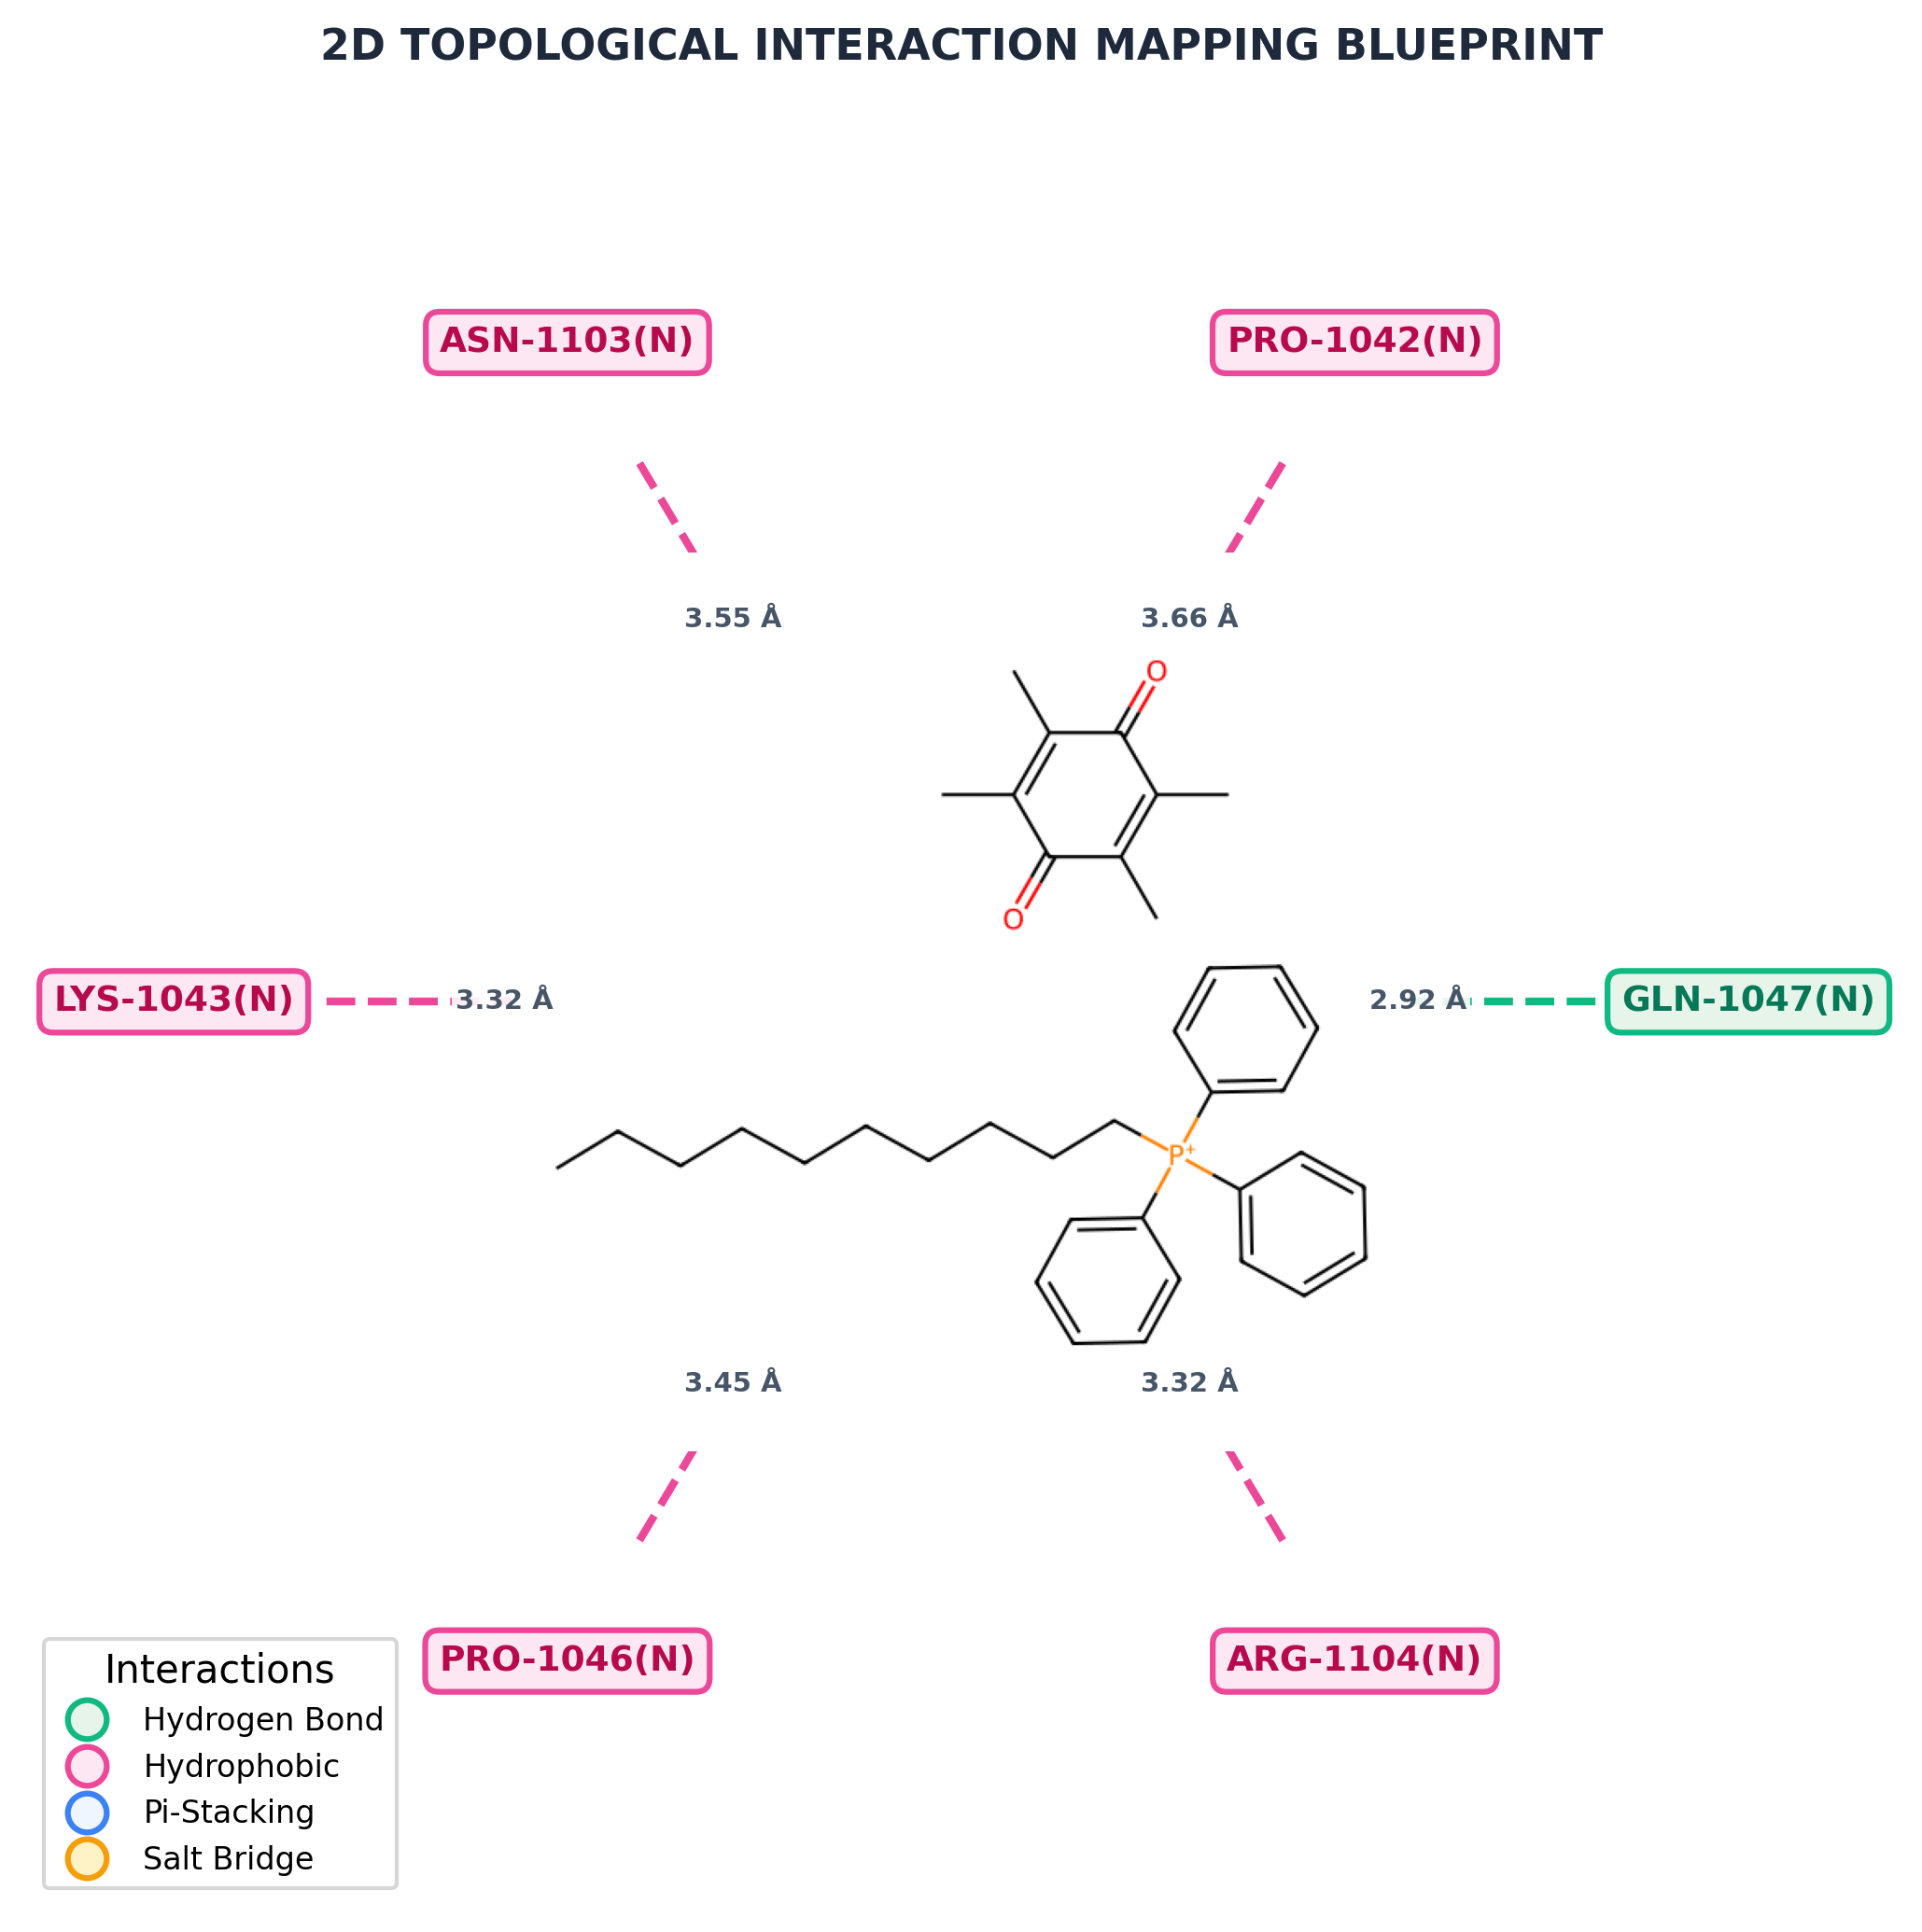

[+] 2D Interaction Diagram rendered and saved -> /content/3O3U_VS/DOCKING/SKQ1/SKQ1_pose_1_2D_blueprint.png

[-] Constructing interactive 3D molecular canvas views...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [23]:
#@title CELL 12.5: Unified 2D/3D Post-Docking Presentation Studio { display-mode: "form" }
#@markdown Select your target compound and adjust the display settings to generate matching 2D and 3D visual graphics.

#@markdown ---
#@markdown ### 🔍 Target Identification:
Ligand_ID = "SKQ1" #@param {type:"string"}
Pose_Number = 1 #@param {type:"slider", min:1, max:9, step:1}

#@markdown ---
#@markdown ### 🏛️ 3D Protein & Pocket Customization:
Protein_Style = "cartoon" #@param ["cartoon", "stick", "sphere", "line"]
Protein_Color = "elegant slate" #@param ["elegant slate", "secondary structure", "marine blue", "spectrum rainbow"]
Show_Binding_Pocket_Sidechains = True #@param {type:"boolean"}
Surface_Display = "Solvent Excluded (SES)" #@param ["none", "Solvent Excluded (SES)", "Solvent Accessible (SAS)"]
Surface_Opacity = 0.25 #@param {type:"slider", min:0, max:1, step:0.05}
Background_Color = "pristine white" #@param ["pristine white", "deep charcoal", "pitch black"]

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import py3Dmol
from IPython.display import display, HTML
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from plip.structure.preparation import PDBComplex

# Hardcoded pristine reference SMILES templates to guarantee perfect 2D bond networks
SMILES_REGISTRY = {
    "SKQ1": "CCCCCCCCCC[P+](c1ccccc1)(c1ccccc1)c1ccccc1.CC1=C(C(=O)C(=C(C1=O)C)C)C",
    "SKQR1": "CCCCCCCCCC[P+](c1ccccc1)(c1ccccc1)c1ccccc1.Cc1cc2c(cc1O)c3c(c(=O)o2)C=C(C(=O)N3)N",
    "NAG": "CC(=O)NC1C(C(OC(C1O)CO)O)O",
    "AQ4": "COCCOc1cc2c(cc1OCCOC)c(ncn2)Nc3ccc(cc3)C#C",
    "LDT": "CCN(CC)CCNc1c2cc(c(cc2ncn1)OC)OC"
}

# Retrieve absolute directory trees from environmental memory
DCK_FLD = os.environ.get('DCK_FLD')
if not DCK_FLD:
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

lig_id = Ligand_ID.strip().upper()
lig_dir = os.path.join(DCK_FLD, lig_id)

prot_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdb') and "_prot_" in f]
pose_file_name = f"{lig_id}_{Pose_Number}.pdb" if f"{lig_id}_{Pose_Number}.pdb" in os.listdir(lig_dir) else f"{lig_id}_1.pdb"
pose_path = os.path.join(lig_dir, pose_file_name)

if not prot_candidates or not os.path.exists(pose_path):
    print(f"[!] Error: Missing required structural components for {lig_id} (Pose {Pose_Number}).")
else:
    receptor_path = os.path.join(DCK_FLD, prot_candidates[0])

    # ---------------------------------------------------------
    # PART 1: COMPILING & RENDERING THE 2D INTERACTION MAP
    # ---------------------------------------------------------
    tmp_complex_path = "tmp_complex.pdb"
    with open(tmp_complex_path, 'w') as out_f:
        for p in [receptor_path, pose_path]:
            with open(p, 'r') as in_f:
                out_f.write(in_f.read())

    mol_complex = PDBComplex()
    mol_complex.load_pdb(tmp_complex_path)
    for ligand in mol_complex.ligands:
        mol_complex.characterize_complex(ligand)
    interactions = mol_complex.interaction_sets
    extracted_bonds = []

    def safe_extract_bond(bond_obj, bond_type):
        resname = getattr(bond_obj, 'restype', getattr(bond_obj, 'resname', 'UNK'))
        resnr = getattr(bond_obj, 'resnr', getattr(bond_obj, 'resnum', '0'))
        reschain = getattr(bond_obj, 'reschain', getattr(bond_obj, 'chain', 'A'))
        dist = 0.0
        for attr in ['distance', 'distance_ad', 'dist']:
            if hasattr(bond_obj, attr):
                val = getattr(bond_obj, attr)
                try:
                    dist = float(val)
                    break
                except (ValueError, TypeError):
                    continue
        return {'res': f"{resname}-{resnr}({reschain})", 'type': bond_type, 'dist': dist}

    if interactions:
        key = list(interactions.keys())[0]
        data = interactions[key]
        for hb in getattr(data, 'hbonds_pdon', []) + getattr(data, 'hbonds_ldon', []):
            extracted_bonds.append(safe_extract_bond(hb, 'Hydrogen Bond'))
        for hp in getattr(data, 'hydrophobic_contacts', getattr(data, 'hydrophobics', [])):
            extracted_bonds.append(safe_extract_bond(hp, 'Hydrophobic'))
        for pi in getattr(data, 'pistacking', getattr(data, 'pi_stacking', [])):
            extracted_bonds.append(safe_extract_bond(pi, 'Pi-Stacking'))
        for sb in getattr(data, 'saltbridges', getattr(data, 'salt_bridges', [])):
            extracted_bonds.append(safe_extract_bond(sb, 'Salt Bridge'))

    if os.path.exists(tmp_complex_path):
        os.remove(tmp_complex_path)

    img_available = False
    template_smiles = SMILES_REGISTRY.get(lig_id)
    if template_smiles:
        try:
            template_mol = Chem.MolFromSmiles(template_smiles)
            if template_mol:
                AllChem.Compute2DCoords(template_mol)
                mol_img = Draw.MolToImage(template_mol, size=(550, 550), fitImage=True)
                img_available = True
        except Exception:
            img_available = False

    print("\n" + "="*85)
    print(f"    R&D GRAPHICS WORKBENCH GENERATION SUMMARY: {lig_id} (POSE {Pose_Number})")
    print("="*85)

    if not extracted_bonds:
        print(f"[!] Notice: No strong non-covalent interactions identified for 2D mapping layout.")
    else:
        unique_bonds = {}
        for b in extracted_bonds:
            if b['res'] not in unique_bonds or b['dist'] < unique_bonds[b['res']]['dist']:
                unique_bonds[b['res']] = b
        bond_list = list(unique_bonds.values())

        color_palette = {
            'Hydrogen Bond': {'edge': '#10B981', 'face': '#E6F4EA', 'text': '#047857'},
            'Hydrophobic':   {'edge': '#EC4899', 'face': '#FCE7F3', 'text': '#B7094C'},
            'Pi-Stacking':   {'edge': '#3B82F6', 'face': '#EFF6FF', 'text': '#1D4ED8'},
            'Salt Bridge':   {'edge': '#F59E0B', 'face': '#FEF3C7', 'text': '#B45309'}
        }

        fig, ax = plt.subplots(figsize=(7, 7), dpi=300)
        ax.set_facecolor('#FFFFFF')

        if img_available:
            imagebox = OffsetImage(mol_img, zoom=0.42)
            ab = AnnotationBbox(imagebox, (0, 0), frameon=False, zorder=2)
            ax.add_artist(ab)
        else:
            ax.text(0, 0, f"{lig_id}\n(Structure)", ha='center', va='center', color='white',
                    fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.5", facecolor="#1E293B"))

        num_residues = len(bond_list)
        radius = 1.35
        angles = np.linspace(0, 2 * np.pi, num_residues, endpoint=False)

        for i, (bond, angle) in enumerate(zip(bond_list, angles)):
            x = radius * np.cos(angle)
            y = radius * np.sin(angle)
            theme = color_palette.get(bond['type'], {'edge': '#64748B', 'face': '#F1F5F9', 'text': '#475569'})
            ax.plot([x * 0.35, x * 0.82], [y * 0.35, y * 0.82], color=theme['edge'], linestyle='--', lw=2.0, zorder=1)
            ax.text(x * 0.58, y * 0.58, f"{bond['dist']:.2f} Å", ha='center', va='center', fontsize=7,
                    fontweight='bold', color='#475569', bbox=dict(boxstyle="square,pad=0.15", facecolor='white', edgecolor='none', alpha=0.9))
            ax.text(x, y, bond['res'], ha='center', va='center', color=theme['text'],
                    fontsize=9, fontweight='bold', bbox=dict(boxstyle="round,pad=0.4", facecolor=theme['face'], edgecolor=theme['edge'], lw=1.5), zorder=4)

        ax.set_xlim(-1.6, 1.6)
        ax.set_ylim(-1.6, 1.6)
        ax.axis('off')

        legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=t['face'],
                           markeredgecolor=t['edge'], markersize=10, markeredgewidth=1.5, label=b_type) for b_type, t in color_palette.items()]
        ax.legend(handles=legend_elements, loc='lower left', title="Interactions", title_fontsize='10', fontsize='8', frameon=True, facecolor='#FFFFFF')

        plt.title(f"2D TOPOLOGICAL INTERACTION MAPPING BLUEPRINT", fontsize=11, fontweight='bold', color='#1E293B', pad=10)
        plt.tight_layout()

        output_2d_path = os.path.join(lig_dir, f"{lig_id}_pose_{Pose_Number}_2D_blueprint.png")
        plt.savefig(output_2d_path, bbox_inches='tight', dpi=300)
        plt.show()
        print(f"[+] 2D Interaction Diagram rendered and saved -> {output_2d_path}")

    # ---------------------------------------------------------
    # PART 2: LOADING & RENDERING THE INTERACTIVE 3D WORKSPACE
    # ---------------------------------------------------------
    with open(receptor_path, 'r') as f:
        protein_data = f.read()
    with open(pose_path, 'r') as f:
        ligand_data = f.read()

    bg_colors = {"pristine white": "#F8FAFC", "deep charcoal": "#1E293B", "pitch black": "#000000"}
    chosen_bg = bg_colors.get(Background_Color, "#F8FAFC")

    print(f"\n[-] Constructing interactive 3D molecular canvas views...")
    viewer = py3Dmol.view(width=900, height=550)
    viewer.setBackgroundColor(chosen_bg)

    # Inject Macromolecular Protein Layer
    viewer.addModel(protein_data, "pdb")
    if Protein_Color == "spectrum rainbow":
        viewer.setStyle({'model': 0}, {Protein_Style: {'colorscheme': 'spectrum'}})
    elif Protein_Color == "secondary structure":
        viewer.setStyle({'model': 0}, {Protein_Style: {'colorscheme': 'ssJmol'}})
    else:
        colors = {"elegant slate": "#94A3B8", "marine blue": "#3B82F6"}
        viewer.setStyle({'model': 0}, {Protein_Style: {'color': colors.get(Protein_Color, "#94A3B8"), 'opacity': 0.85}})

    # Inject Docked Compound Cores Layer
    viewer.addModel(ligand_data, "pdb")
    viewer.setStyle({'model': 1}, {'stick': {'colorscheme': 'cyanCarbon', 'radius': 0.30}, 'sphere': {'colorscheme': 'cyanCarbon', 'scale': 0.22}})

    # Optional: Isolate and Highlight Sidechains Touchpoints
    if Show_Binding_Pocket_Sidechains:
        viewer.setStyle({'model': 0, 'within': {'distance': 5.0, 'sel': {'model': 1}}},
                        {'stick': {'colorscheme': 'elementOres', 'radius': 0.18}})

    # Optional: Project Solvent Excluded / Accessible Cavity Clouds
    if Surface_Display != "none":
        surf_modes = {"Solvent Excluded (SES)": py3Dmol.SES, "Solvent Accessible (SAS)": py3Dmol.SAS}
        viewer.addSurface(surf_modes.get(Surface_Display, py3Dmol.SES), {'opacity': Surface_Opacity, 'color': '#CBD5E1'}, {'model': 0})

    viewer.zoomTo({'model': 1})
    viewer.show()

    # Inject High-Resolution Image Downloader UI Card
    html_downloader = """
    <div style="margin-top: 15px; font-family: sans-serif; background-color: #F1F5F9; padding: 15px; border-radius: 8px; border: 1px solid #E2E8F0;">
        <h4 style="margin: 0 0 8px 0; color: #1E293B;">💾 Export Workspace Figures:</h4>
        <button onclick="export3DStudioImage()" style="background-color: #3B82F6; color: white; border: none; padding: 10px 18px; font-size: 13px; font-weight: bold; border-radius: 6px; cursor: pointer; margin-right: 10px;">
            📸 Download 3D Complex View (.png)
        </button>
        <span style="font-size: 12px; color: #64748B;">
            <b>Instructions:</b> Adjust the 3D model orientation directly above with your mouse, then click the blue button to capture your custom viewport angle.
        </span>
    </div>
    <script>
    function export3DStudioImage() {
        var canvasList = document.querySelectorAll('canvas');
        if (canvasList.length > 0) {
            var targetCanvas = canvasList[canvasList.length - 1];
            var dataURL = targetCanvas.toDataURL("image/png");
            var downloadAnchor = document.createElement('a');
            downloadAnchor.href = dataURL;
            downloadAnchor.download = '""" + f"{lig_id}_pose_{Pose_Number}_3D_mesh_view.png" + """';
            document.body.appendChild(downloadAnchor);
            downloadAnchor.click();
            document.body.removeChild(downloadAnchor);
        } else {
            alert("Error: Active WebGL drawing layer not located.");
        }
    }
    </script>
    """
    display(HTML(html_downloader))